# Предобработка и разметка исходных данных

In [2]:
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import os
import datetime
import shutil
import numpy as np
import matplotlib.pyplot as plt
from exif import Image as exif_image

In [6]:
images = list(Path('raw_data').rglob('*'))

## Уменьшим размер изображений

In [15]:
larger_side_resized = 640

In [20]:
for im_path in tqdm(images):
    im = Image.open(im_path).convert('RGB')
    larger_side = max(im.width, im.height)
    resize_koeff = larger_side / larger_side_resized
    image = im.resize((int(im.width / resize_koeff), int(im.height / resize_koeff)))
    image.save(Path('data') / im_path.name)

100%|█████████████████████████████████████████| 309/309 [01:00<00:00,  5.12it/s]


## Составим таблицу с датой-временем создания фотографии

In [46]:
file_names = []
datetimes = []
for im_path in tqdm(images):
    with open(im_path, 'rb') as fp:
        image = exif_image(fp)
    file_names.append(im_path.name)
    datetimes.append(image.datetime_original)

100%|████████████████████████████████████████| 299/299 [00:00<00:00, 381.40it/s]


In [48]:
image_meta = pd.DataFrame()

In [49]:
image_meta['name'] = file_names
image_meta['timestamp'] = datetimes

In [56]:
image_meta['datetime'] = image_meta['timestamp'].apply(lambda x: datetime.datetime.strptime(x, '%Y:%m:%d %H:%M:%S'))

In [61]:
image_meta['date'] = image_meta['datetime'].apply(lambda x: x.date().isoformat())

In [62]:
image_meta.head()

,name,timestamp,datetime,date
0,IMG_20221201_131637.jpg,2022:12:01 13:16:38,2022-12-01 13:16:38,2022-12-01
1,IMG_20220422_185636.jpg,2022:04:22 18:56:38,2022-04-22 18:56:38,2022-04-22
2,P7081020.JPG,2023:07:08 19:00:35,2023-07-08 19:00:35,2023-07-08
3,IMG_20221025_134504.jpg,2022:10:25 13:45:06,2022-10-25 13:45:06,2022-10-25
4,IMG_20221218_141745.jpg,2022:12:18 14:17:47,2022-12-18 14:17:47,2022-12-18


In [63]:
image_meta.to_parquet('embeddings&markup/image_metadata.pq')

**Сгруппируем фото по датам в отдельные папки**

In [64]:
image_meta['date'].nunique()

67

In [65]:
image_groups = image_meta.groupby('date').agg({'name': list}).reset_index()

In [67]:
image_groups.head()

,date,name
0,2022-03-31,[IMG_20220331_121233.jpg]
1,2022-04-08,"[IMG_20220408_152234.jpg, IMG_20220408_152229...."
2,2022-04-13,"[IMG_20220413_111051.jpg, IMG_20220413_111046...."
3,2022-04-14,"[IMG_20220414_123922.jpg, IMG_20220414_123925...."
4,2022-04-18,"[IMG_20220418_195916.jpg, IMG_20220418_195927...."


**Распределение размеров групп**

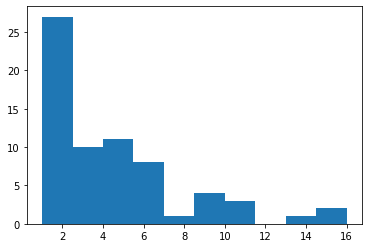

In [69]:
plt.hist(image_groups['name'].apply(lambda x: len(x)));

**Группы получились сравнительно небольшие: их можно почистить вручную**

In [80]:
for i, d, files in tqdm(image_groups.itertuples()):
    os.mkdir(str(i))
    for file in files:
        shutil.copyfile(f'data/{file}', f'{str(i)}/{file}')

67it [00:00, 1950.11it/s]


## Делаем разметку групп (кластеров) фото

**Перегрупируем фото в папках вручную, разделим фото с одной датой, которые не относятся к одному кластеру - разложим их по разным папкам. Создадим ярлыки для групп: пусть название (номер) каждой папки и будет ярлыком**

---

## После ручной разметки

Теперь фото разложены по папкам в соответствии с принадлежностью к группе

In [4]:
image_meta = pd.read_parquet('embeddings&markup/image_metadata.pq')

In [5]:
image_meta.head(3)

,name,timestamp,datetime,date
0,IMG_20221201_131637.jpg,2022:12:01 13:16:38,2022-12-01 13:16:38,2022-12-01
1,IMG_20220422_185636.jpg,2022:04:22 18:56:38,2022-04-22 18:56:38,2022-04-22
2,P7081020.JPG,2023:07:08 19:00:35,2023-07-08 19:00:35,2023-07-08


In [6]:
image_paths = list(Path('data_markup').rglob('*'))

In [11]:
image_paths = [p for p in image_paths if len(str(p).split('/')) > 2]

In [12]:
len(image_paths)

299

**Имя родительской папки для каждого фото - это и есть id группы (кластера)**

In [17]:
image_paths[0].parent.name

'40'

In [14]:
image_paths[:10]

[PosixPath('data_markup/40/IMG_20221130_132944.jpg'),
 PosixPath('data_markup/1089/IMG_20230528_203741.jpg'),
 PosixPath('data_markup/3/IMG_20220414_123925.jpg'),
 PosixPath('data_markup/26/IMG_20220730_185131_1.jpg'),
 PosixPath('data_markup/26/IMG_20220730_185131.jpg'),
 PosixPath('data_markup/1002/IMG_20220413_111049.jpg'),
 PosixPath('data_markup/1023/IMG_20220520_095833.jpg'),
 PosixPath('data_markup/1023/IMG_20220520_095835.jpg'),
 PosixPath('data_markup/49/IMG_20230208_201717.jpg'),
 PosixPath('data_markup/49/IMG_20230208_201715.jpg')]

**Создадим файл с разметкой кластеров:**

In [15]:
cluster_data = pd.DataFrame()
image_names = []
cluster_id = []

In [18]:
for p in image_paths:
    image_names.append(p.name)
    cluster_id.append(int(p.parent.name))

In [19]:
cluster_data['name'] = image_names
cluster_data['cluster_id'] = cluster_id

In [20]:
cluster_data.head(3)

,name,cluster_id
0,IMG_20221130_132944.jpg,40
1,IMG_20230528_203741.jpg,1089
2,IMG_20220414_123925.jpg,3


In [24]:
image_markup = image_meta[['name', 'datetime']].merge(cluster_data, on='name')

In [25]:
image_markup.head()

,name,datetime,cluster_id
0,IMG_20221201_131637.jpg,2022-12-01 13:16:38,1076
1,IMG_20220422_185636.jpg,2022-04-22 18:56:38,7
2,P7081020.JPG,2023-07-08 19:00:35,61
3,IMG_20221025_134504.jpg,2022-10-25 13:45:06,1067
4,IMG_20221218_141745.jpg,2022-12-18 14:17:47,44


In [26]:
image_markup.to_parquet('embeddings&markup/image_markup.pq')

### Посмотрим на статистики полученных кластеров

In [8]:
image_markup = pd.read_parquet('embeddings&markup/image_markup.pq')

In [9]:
cluster_sizes = image_markup.groupby('cluster_id')['name'].nunique()

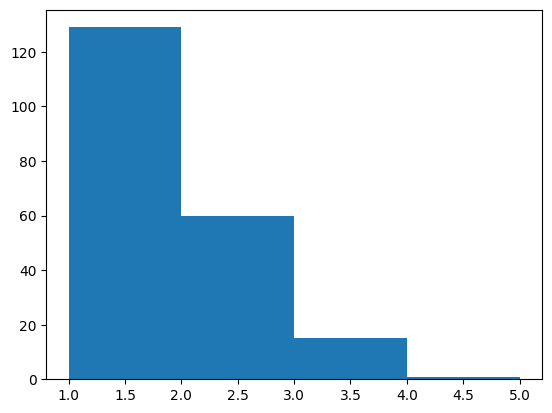

In [15]:
plt.hist(cluster_sizes, bins=4);

**Максимальный размер кластера**

In [16]:
cluster_sizes.max()

5

**Сколько единичных кластеров**

In [17]:
(cluster_sizes == 1).sum()

129

Таким образом, 170 фото из 299 сгруппировались в кластеры размером от 2 до 5 фото.

In [18]:
image_markup.head(3)

,name,datetime,cluster_id,n_samples
0,IMG_20221201_131637.jpg,2022-12-01 13:16:38,1076,1
1,IMG_20220422_185636.jpg,2022-04-22 18:56:38,7,2
2,P7081020.JPG,2023-07-08 19:00:35,61,2


### Рассмотрим примеры кластеров

In [20]:
mask1 = image_markup['n_samples'] > 1

In [21]:
sample_clusters = np.random.choice(image_markup.loc[mask1, 'cluster_id'].values, 5, replace=False)

In [22]:
sample_clusters

array([  33, 1053,   61, 1019, 1098])

In [23]:
def get_sample_images(cluster_id, df):
    image_paths = [str(Path('data') / name) for name in df.loc[df['cluster_id'] == cluster_id, 'name']]
    images = [Image.open(p).convert('RGB') for p in image_paths]
    return images

Кластер 33

In [24]:
images1 = get_sample_images(33, image_markup)

In [25]:
len(images1)

3

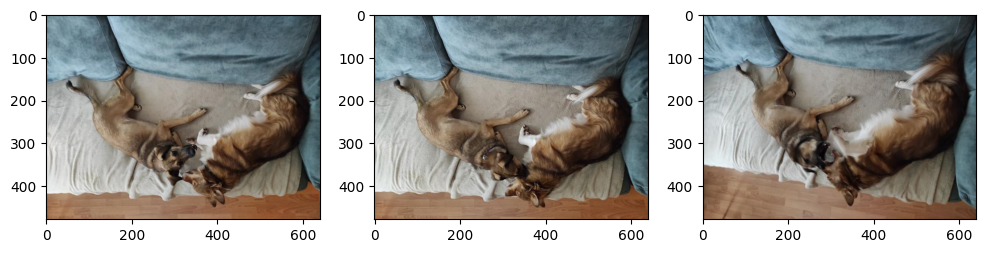

In [27]:
fig, ax = plt.subplots(figsize=(12, 4), nrows=1, ncols=3)
ax[0].imshow(images1[0])
ax[1].imshow(images1[1])
ax[2].imshow(images1[2])

Кластер 1053

In [31]:
images2 = get_sample_images(1053, image_markup)

In [32]:
len(images2)

5

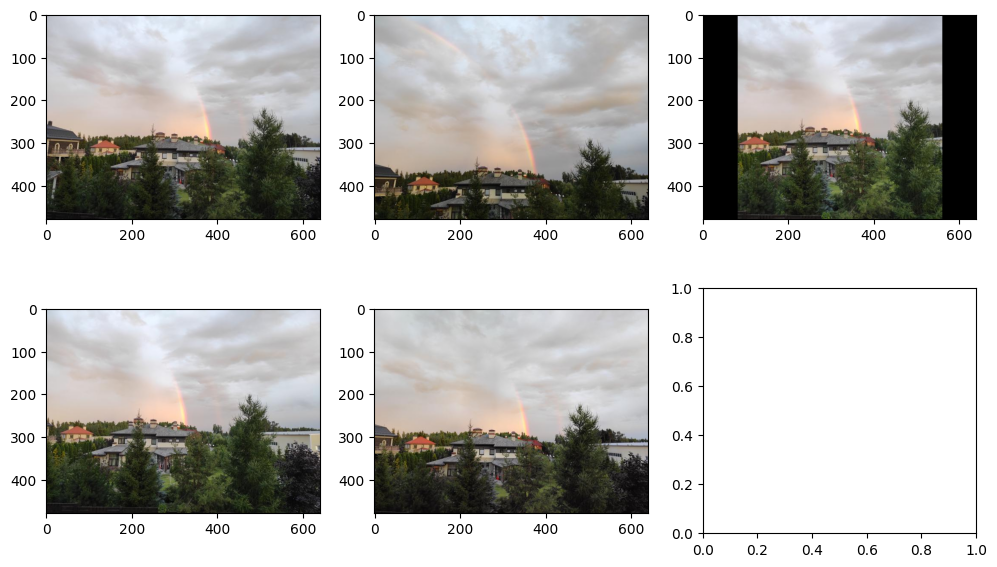

In [36]:
fig, ax = plt.subplots(figsize=(12, 7), nrows=2, ncols=3)
ax[0, 0].imshow(images2[0])
ax[0, 1].imshow(images2[1])
ax[0, 2].imshow(images2[2].rotate(-90))
ax[1, 0].imshow(images2[3])
ax[1, 1].imshow(images2[4])

Кластер 61

In [37]:
images3 = get_sample_images(61, image_markup)

In [40]:
len(images3)

2

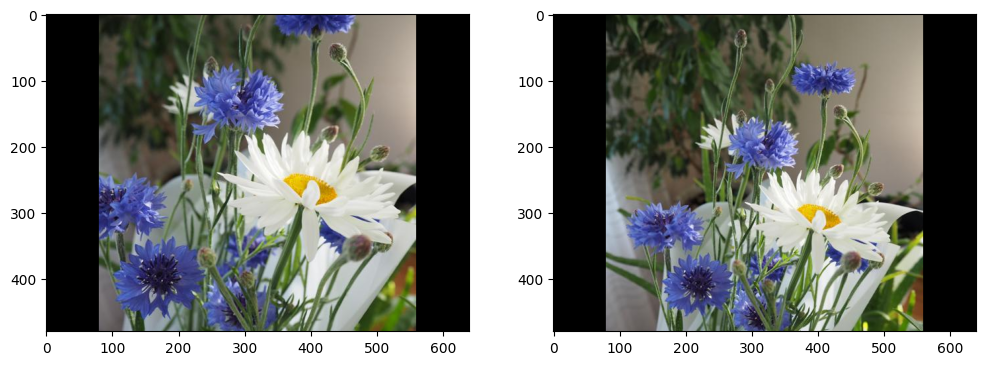

In [42]:
fig, ax = plt.subplots(figsize=(12, 7), nrows=1, ncols=2)
ax[0].imshow(images3[0].rotate(-90))
ax[1].imshow(images3[1].rotate(-90))